### Plot Figure 3A&B according to results in _results/230827_trainOn_mouse_embryonic_development_kFold_testOnYZdata0809_

In [1]:
# -*-coding:utf-8 -*-
import os
import sys

if os.getcwd().split("/")[-1] != "TemporalVAE":
    os.chdir("..")
sys.path.append(os.getcwd())


from utils.utils_Dandan_plot import calculate_real_predict_corrlation_score, umap_vae_latent_space_adata_version
import pandas as pd
import json
import scanpy as sc
import matplotlib.pyplot as plt
# 2023-11-03 11:38:31
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from collections import Counter
from utils.utils_Dandan_plot import colors_tuple_hexadecimalColorCode,plt_umap_byScanpy
import numpy as np
import anndata as ad

global_folder_path = "results/230827_trainOn_mouse_embryonic_development_kFold_testOnYZdata0809/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_dim50_timeembryoneg5to5_epoch100_dropDonorno_mouseEmbryonicDevelopment_embryoneg5to5"

In [2]:
def plot_kfold_mouseAtlas():
    file_name = f"{global_folder_path}/SuperviseVanillaVAE_regressionClfDecoder_plot_on_all_test_donor_timeembryoneg5to5_celltype_update_testCLF.json"
    cell_time_info_file = "data/" \
                          "mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/cell_with_time.csv"
    print(f"preditced time file is {file_name} \n,cell file which stores the real time is {cell_time_info_file}")
    with open(file_name, "r") as json_file:
        data_list = []
        for line in json_file:
            json_obj = json.loads(line)
            data_list.append(json_obj)
    # get donor list from json file
    data_dic = data_list[0]
    donor_list = list(data_dic.keys())
    donor_list = list(set([i.replace("_pseudotime", "").replace("_cellid", "") for i in donor_list]))

    # only plot atlas donor
    donor_atlas_list = [i for i in donor_list if "stereo" not in i]
    # donor_stereo_list = [i for i in donor_list if "stereo" in i]

    print(f"donor all is {donor_list},\nonly plot atlas donor {donor_atlas_list}.")

    cell_time_atlas_pd = pd.read_csv(cell_time_info_file, sep="\t", index_col=0)
    donor_atlas_df = pd.DataFrame(columns=["pseudotime", "time", "donor"])
    for _donor in donor_atlas_list:
        _time = cell_time_atlas_pd[cell_time_atlas_pd['donor'] == _donor]['time'][0]
        _temp_df = pd.DataFrame(dict(pseudotime=data_dic[_donor + "_pseudotime"], time=_time, donor=_donor))
        donor_atlas_df = pd.concat([donor_atlas_df, _temp_df], axis=0)

    corr_stats = calculate_real_predict_corrlation_score(donor_atlas_df["pseudotime"], donor_atlas_df["time"])
    print(f"=== data correlation: \n{corr_stats}")
    boxPlot_df = donor_atlas_df.copy()
    # 计算每个 "time" 值对应的 "pseudotime" 计数
    time_counts = boxPlot_df.groupby("time")["pseudotime"].count().reset_index()
    donor_counts = boxPlot_df.groupby("time")["donor"].nunique().reset_index()
    # 获取所有唯一的 "time" 值
    unique_times = list(time_counts["time"])
    # 使用颜色映射创建一个颜色字典
    # colors = colors_tuple()
    # cmap = colors[:len(unique_times)]
    cmap = plt.get_cmap('turbo')(np.linspace(0, 1, len(unique_times)))
    color_dict = dict(zip(unique_times, cmap))
    # 根据 "time" 值从颜色字典中获取颜色
    boxPlot_df["color"] = boxPlot_df["time"].map(color_dict)

    # fig, ax = plt.subplots(1, 1, figsize = (20, 7))
    plt.figure(figsize=(23, 10))  # 设置宽度为10，高度为6
    # 设置 Seaborn 主题和风格
    sns.set_theme(style="whitegrid")
    # 创建小提琴图，并指定 x 和 y 轴，设置颜色
    sns.violinplot(x="time", y="pseudotime", data=boxPlot_df, palette=color_dict, bw=0.2, scale='width', saturation=1)
    plt.title("Violin Plot of k-fold test.")
    plt.xlabel("Embryo stage")
    plt.ylabel("Predicted biological time")
    # 添加颜色的图例
    marksize_dic = {time: np.log(time_counts[time_counts['time'] == time]['pseudotime'].values[0]) for time in unique_times}

    _temp = {time: donor_counts[donor_counts['time'] == time]['donor'].values[0] for time in unique_times}
    _temp_cmap = plt.get_cmap('RdPu')(np.linspace(0, 1, 1 + len(np.unique(list(_temp.values())))))
    _temp_makerfacecolor = {1: _temp_cmap[1], 2: _temp_cmap[2], 3: _temp_cmap[3], 4: _temp_cmap[4], 5: _temp_cmap[5], 12: _temp_cmap[6]}
    makerfacecolor_dic = {time: _temp_makerfacecolor[_temp[time]] for time in unique_times}
    # color_dict = dict(zip(unique_times, cmap))

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                  label=f"{time_counts[time_counts['time'] == time]['pseudotime'].values[0]} from {donor_counts[donor_counts['time'] == time]['donor'].values[0]} embryo",
                                  markerfacecolor=makerfacecolor_dic[time], markersize=marksize_dic[time]) for time in unique_times]
    # legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
    #                               label=f"{time_counts[time_counts['time'] == time]['pseudotime'].values[0]} from {donor_counts[donor_counts['time'] == time]['donor'].values[0]} embryo",
    #                               markerfacecolor=color_dict[time], markersize=marksize_dic[time]) for time in unique_times]

    plt.legend(handles=legend_elements, title="Cell Num", bbox_to_anchor=(1.01, -0.10), loc="lower left", borderaxespad=0, prop={'size': 10})
    # plt.legend(handles=legend_elements, title="Cell Num", bbox_to_anchor=(1.01, 0), loc="lower left", borderaxespad=0, prop={'size': 5.6})
    plt.xticks(size=11, rotation=90)


    plt.savefig(f"{file_name.replace('.json', '.pdf')}")
    plt.savefig(f"{file_name.replace('.json', '.png')}", dpi=350)
    print("Finish save images at: {}".format(f"{file_name.replace('.json', '.png')}"))
    plt.show()
    plt.close()

    return


def cal_pc1pc2(adata, attr, save_path, grey_indexes=None, ncol=1, custom_palette_bool=False):
    X_standardized = StandardScaler().fit_transform(adata.X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_standardized)
    data_df_all = pd.DataFrame(data=X_pca, index=adata.obs_names, columns=["pc1", "pc2"])
    data_df_all[attr] = adata.obs[attr].values
    data_df_all.to_csv(f"{save_path}/latentSpace_pc1pc2_{attr}.csv")
    if grey_indexes is not None:
        # 将索引列表转换为布尔数组
        grey_mask = data_df_all.index.isin(grey_indexes)
        # 绘制灰色点
        # df_grey = data_df_all[grey_mask].copy(deep=True)
        # sns.scatterplot(x="pc1", y="pc2", data=df_grey, s=3, alpha=0.4,color="grey")
        # plt.scatter(df.loc[grey_mask, "pc1"], df.loc[grey_mask, "pc2"], color="grey", s=3, alpha=0.5)
        # 绘制其他点
        df_normal = data_df_all[~grey_mask]
        df_normal_copy = pd.DataFrame(data=df_normal.values, columns=["pc1", "pc2", attr])
        # if custom_palette_bool:
        #     custom_palette = colors_tuple_hexadecimalColorCode()[:len(np.unique(df_normal[attr]))]
        #     plot_pc1pc2(df_normal_copy, attr, save_path, pca, ncol=ncol, custom_palette=custom_palette)
        # else:
        # df_normal_copy = df_normal_copy.sort_values(by=attr)
        plot_pc1pc2(df_normal_copy, attr, save_path, pca, ncol=ncol)
    else:
        plot_pc1pc2(data_df_all.copy(deep=True), attr, save_path, pca, ncol=ncol)


def plot_pc1pc2(data_df, attr, save_path, pca, ncol=1, custom_palette=None):
    plt.close()
    plt.figure(figsize=(8, 8))
    if custom_palette is not None:
        sns.scatterplot(x="pc1", y="pc2", data=data_df, hue=attr, s=5, alpha=0., palette=list(custom_palette))
    else:
        sns.scatterplot(x="pc1", y="pc2", data=data_df, hue=attr, s=5, alpha=0.7, palette="turbo")
    # 添加图例和标签
    plt.xlabel(f'pc1: {round(pca.explained_variance_ratio_[0], 3) * 100}%')
    plt.ylabel(f'pc2: {round(pca.explained_variance_ratio_[1], 3) * 100}%')
    plt.title(f'Scatter Plot with {attr.capitalize().split("_")[0]} Labels.', y=-0.12)
    plt.legend(ncol=ncol, title=attr.capitalize().split("_")[0], loc="upper left", markerscale=0.8, prop={'size': 7})
    # plt.legend(ncol=ncol, title=attr.capitalize(), loc="lower right", bbox_to_anchor=(1.0, 0.1),
    #            bbox_transform=plt.gcf().transFigure, markerscale=0.8, prop={'size': 5})
    # save
    plt.savefig(f"{save_path}/latentSpace_pc1pc2_{attr}.png", format="png", transparent=True, dpi=400)
    plt.show()
    plt.close()

def plt_latentSpace_mouseAtlas():
    save_path = global_folder_path
    print(save_path)
    adata = sc.read_h5ad(f"{save_path}/latent_mu.h5ad") # adata_atlas = adata[adata.obs["batch"] != -1]

    # ------- plot for mouse atlas, but too many cell types and cells, so select 1/10 cells and top 10 cell types.----------
    random.seed(123)
    random_indices = random.sample(range(adata.shape[0]), int(adata.n_obs / 10), )
    adata_subCells = adata[random_indices, :].copy()
    celltype_dic = Counter(adata_subCells.obs["celltype_update"])
    top_10_celltype = sorted(celltype_dic, key=celltype_dic.get, reverse=True)[:10]
    adata_subCells2 = adata_subCells[adata_subCells.obs.loc[adata_subCells.obs["celltype_update"].isin(list(top_10_celltype))].index].copy()
    # cal_pc1pc2(adata_subCells2.copy(), "day", save_path, custom_palette_bool=True, ncol=3)  # ["day", "embryo_id","experimental_batch","batch"]
    # cal_pc1pc2(adata_subCells2.copy(), "celltype_update", save_path, custom_palette_bool=True)  # ["day", "embryo_id","experimental_batch","batch"]
    plt_umap_byScanpy(adata_subCells2.copy(), ["time", "celltype_update"], save_path, mode="read",figure_size=(7,6),color_map="turbo")


    return



preditced time file is results/230827_trainOn_mouse_embryonic_development_kFold_testOnYZdata0809/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_dim50_timeembryoneg5to5_epoch100_dropDonorno_mouseEmbryonicDevelopment_embryoneg5to5/SuperviseVanillaVAE_regressionClfDecoder_plot_on_all_test_donor_timeembryoneg5to5_celltype_update_testCLF.json 
,cell file which stores the real time is data/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/cell_with_time.csv
donor all is ['embryo_47', 'embryo_38', 'embryo_68', 'embryo_64', 'embryo_45', 'embryo_58', 'embryo_1', 'embryo_27', 'embryo_10', 'embryo_55', 'embryo_34', 'embryo_19', 'embryo_62', 'embryo_39', 'embryo_57', 'embryo_17', 'embryo_7', 'embryo_22', 'embryo_31', 'embryo_69', 'embryo_29', 'embryo_3', 'embryo_52', 'embryo_59', 'embryo_46', 'embryo_49', 'embryo_12', 'embryo_25', 'embryo_60', 'embryo_65', 'embryo_30', 'emb

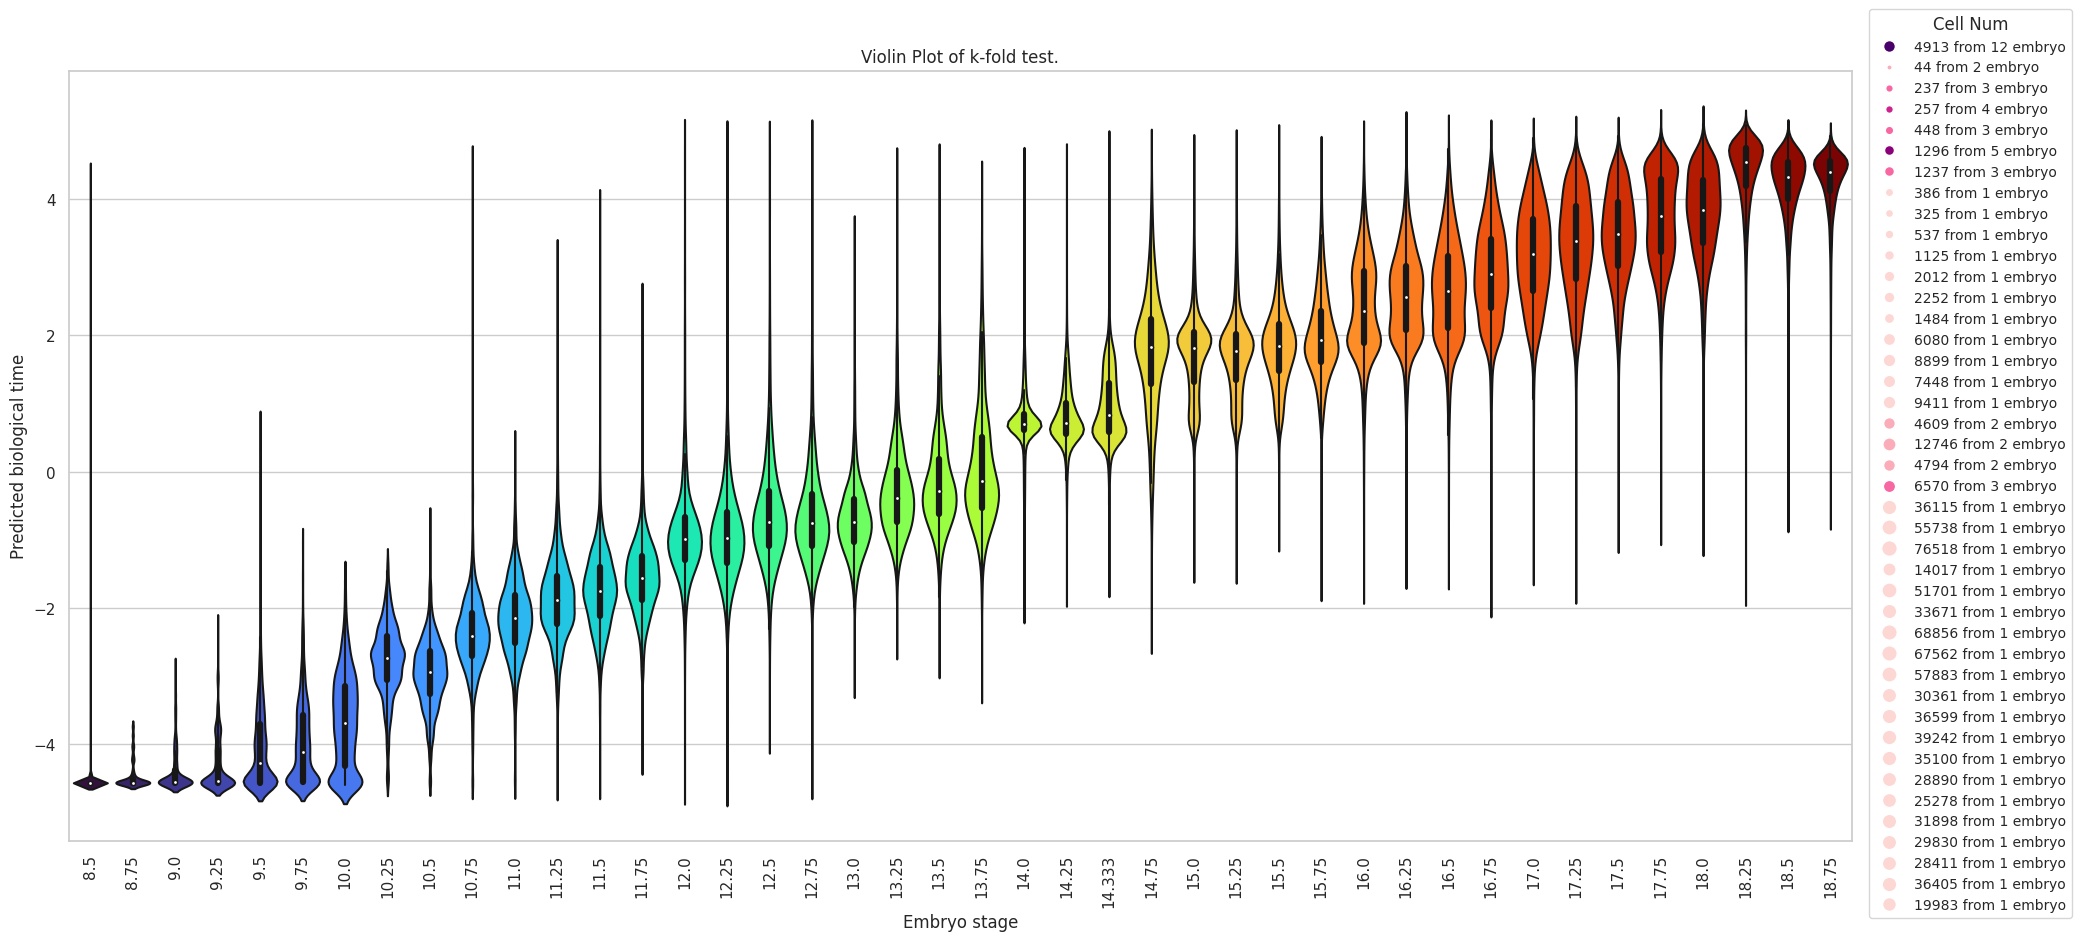

results/230827_trainOn_mouse_embryonic_development_kFold_testOnYZdata0809/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_dim50_timeembryoneg5to5_epoch100_dropDonorno_mouseEmbryonicDevelopment_embryoneg5to5


2024-05-10 18:48:36.652336: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-10 18:48:36.692676: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-10 18:48:36.693481: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-10 18:48:37.711747: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


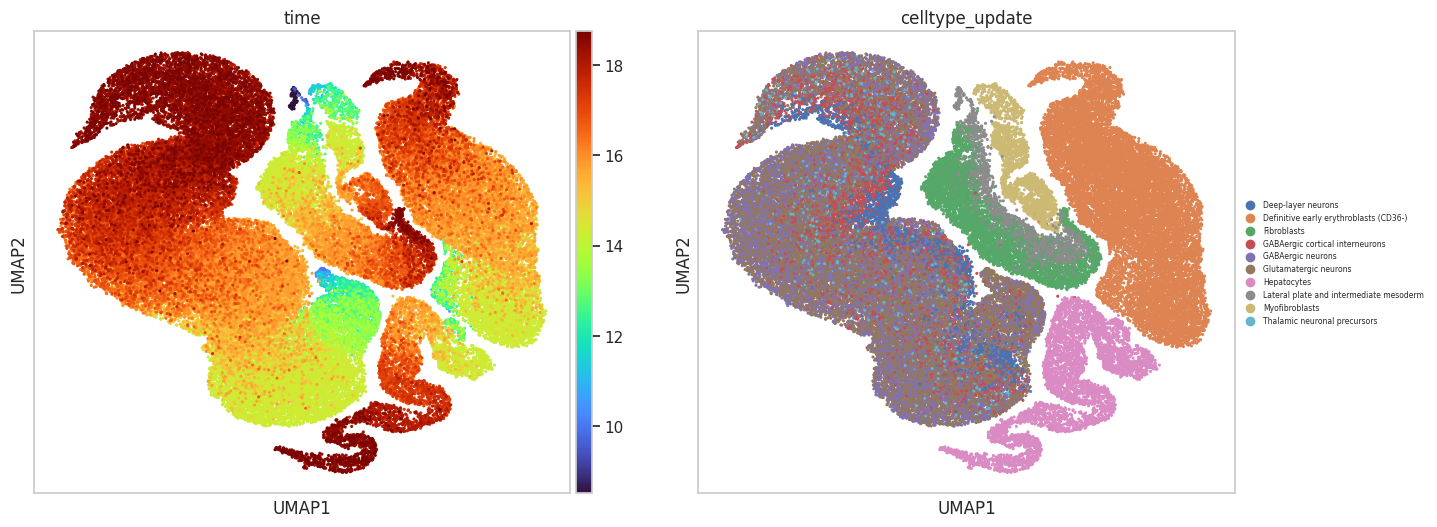

figure save as results/230827_trainOn_mouse_embryonic_development_kFold_testOnYZdata0809/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_dim50_timeembryoneg5to5_epoch100_dropDonorno_mouseEmbryonicDevelopment_embryoneg5to5/latentSpace_umap_byScanpy.png


In [3]:
plot_kfold_mouseAtlas()
plt_latentSpace_mouseAtlas()